# Marine 48h Forecast — Dual-Channel iTransformer Ablation (18 "good" parameters)

Tests one specific 2025 research idea against the current iTransformer baseline, restricted to the
18 parameters iTransformer already handles well (the hard 6 — visibility ×4, precipitation ×2 — are
out of scope here; see `Marine_Forecast_RealEMS_Hybrid_iTransformer_*.ipynb` for that line of work).

**The idea (from `iTransformer_Research_Improvements.md`, "Hybrid Channel-Dependent/Independent
Strategies, 2025"):** the current iTransformer is purely **channel-dependent** — it only ever attends
*across* parameters (variate-as-token attention), with no explicit branch for a parameter's *own*
temporal autocorrelation pattern. Recent work adds a small **channel-independent temporal branch**
(dilated depthwise-separable convolution per channel, no cross-channel mixing) and fuses it with the
existing channel-dependent attention branch — reported +7.3% MSE / +3.2% MAE across 13 datasets.

**Why this one specifically, and not the others in the research doc:** most of the 2025 variants
(Feature-Enhanced iTransformer, Prototypical Channel Normalization) target problems we don't have —
hundreds of variates, unknown/varying channel counts, graph-structured multi-site data. The dual-channel
idea is the only one addressing an actual structural gap in *our* model: zero explicit per-channel
temporal modeling.

**Important guardrail, given `Marine_Forecast_RealEMS_Hybrid_iTransformer_TimeXer.ipynb` (v4) just
demonstrated that added model capacity can regress results on this 28-day dataset:** this notebook adds
the temporal branch with a **residual fusion** (`fused = spatial_branch + fusion(concat)`), so if the
new branch learns nothing useful, the model degrades gracefully toward the existing baseline rather than
actively overriding it. The verdict in Section 6 is the actual test — if it doesn't help on a majority
of the 18 parameters, the recommendation is to revert and keep the existing baseline, not keep the
larger model anyway.

Standalone — does not modify any other notebook, dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]
print(f"This ablation covers the {len(GOOD_PARAMS)} 'good' parameters only: {GOOD_PARAMS}")

This ablation covers the 21 'good' parameters only: ['airTemperature', 'airPressure', 'relativeHumidity', 'dewPointTemperature', 'windSpeed', 'globalRadiation', 'currentSpeed', 'tideLevel', 'waterTemperature', 'conductivity', 'salinity', 'significantWaveHeight', 'significantWavePeriod', 'peakWaveEnergyPeriod', 'zeroCrossingPeriod', 'windDirection_sin', 'windDirection_cos', 'currentDirection_sin', 'currentDirection_cos', 'compass_sin', 'compass_cos']


## 2. Train/test split, duplicate reconstruction fit, scaling

In [3]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
good_idx = [feature_cols.index(c) for c in GOOD_PARAMS]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")

Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


In [4]:
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))

## 3. Shared training data and training loop

In [5]:
def make_direct_windows(scaled_df, lookback, horizon, out_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, out_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_direct, Y_good = make_direct_windows(train_scaled, LOOKBACK, HORIZON, good_idx)
X_t, Y_good_t = torch.from_numpy(X_direct), torch.from_numpy(Y_good)
n_val = max(1, int(0.1 * len(X_t)))
X_tr, Y_tr = X_t[:-n_val], Y_good_t[:-n_val]
X_val, Y_val = X_t[-n_val:], Y_good_t[-n_val:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)


def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64, lr=1e-3,
                 patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:24s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

## 4. Model A — Baseline iTransformer (channel-dependent only, unchanged architecture)

In [6]:
class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.out_idx]

baseline = ITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4, n_layers=2)
baseline = train_model(baseline, X_tr, Y_tr, X_val, Y_val, epochs=150, patience=20, name="Baseline-iTransformer")

with torch.no_grad():
    baseline_pred_scaled = baseline(last_window.to(device))[0].cpu().numpy()
baseline_preds_real = baseline_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
baseline_pred_df = pd.DataFrame(baseline_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("Baseline iTransformer 48h forecast complete.")

  [Baseline-iTransformer] epoch   1/150  val_loss=0.4280  epoch_time=1.1s  elapsed=1s


  [Baseline-iTransformer] epoch   2/150  val_loss=0.3269  epoch_time=0.8s  elapsed=2s


  [Baseline-iTransformer] epoch   3/150  val_loss=0.2639  epoch_time=1.1s  elapsed=3s


  [Baseline-iTransformer] epoch   4/150  val_loss=0.2357  epoch_time=1.0s  elapsed=4s


  [Baseline-iTransformer] epoch   5/150  val_loss=0.2015  epoch_time=0.8s  elapsed=5s


...

  [Baseline-iTransformer] epoch 147/150  val_loss=0.0368  epoch_time=1.0s  elapsed=149s


  [Baseline-iTransformer] epoch 148/150  val_loss=0.0366  epoch_time=0.9s  elapsed=150s


  [Baseline-iTransformer] epoch 149/150  val_loss=0.0367  epoch_time=1.0s  elapsed=151s


  [Baseline-iTransformer] epoch 150/150  val_loss=0.0365  epoch_time=0.9s  elapsed=152s


Baseline-iTransformer    best_val_loss=0.0365  epochs_run=150  time=151.6s
Baseline iTransformer 48h forecast complete.


## 5. Model B — Dual-Channel iTransformer (+ channel-independent temporal branch)
A dilated depthwise-separable-convolution branch (channel-independent, no cross-channel mixing) runs in parallel with the existing channel-dependent attention branch. Fused via a residual linear layer, so a useless temporal branch decays toward the baseline rather than overriding it.

In [7]:
class TemporalBranch(nn.Module):
    # Channel-independent: each of the n_channels gets its own depthwise filters, no cross-channel mixing.
    def __init__(self, n_channels, d_t=16, kernel_size=5, dilations=(1, 2, 4)):
        super().__init__()
        self.n_channels, self.d_t = n_channels, d_t
        self.convs = nn.ModuleList([
            nn.Conv1d(n_channels, n_channels * d_t, kernel_size, dilation=d,
                      padding=d * (kernel_size - 1) // 2, groups=n_channels)
            for d in dilations
        ])
        self.act = nn.GELU()

    def forward(self, x):                       # x: (B, lookback, n_channels)
        xt = x.transpose(1, 2)                  # (B, n_channels, lookback)
        out = 0
        for conv in self.convs:
            out = out + self.act(conv(xt))       # (B, n_channels*d_t, lookback)
        out = out.mean(dim=2)                    # global average pool over time
        return out.view(-1, self.n_channels, self.d_t)   # (B, n_channels, d_t)


class DualChannelITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, d_t=16, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.temporal = TemporalBranch(n_features, d_t=d_t)
        self.fusion = nn.Linear(d_model + d_t, d_model)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)   # channel-dependent (spatial)
        tok = self.encoder(tok)
        temp = self.temporal(x)                                         # channel-independent (temporal)
        fused = tok + self.fusion(torch.cat([tok, temp], dim=-1))        # residual fusion
        out = self.head(fused)
        return out.transpose(1, 2)[:, :, self.out_idx]

dualchannel = DualChannelITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4,
                                       n_layers=2, d_t=16)
dualchannel = train_model(dualchannel, X_tr, Y_tr, X_val, Y_val, epochs=150, patience=20,
                           name="DualChannel-iTransformer")

with torch.no_grad():
    dual_pred_scaled = dualchannel(last_window.to(device))[0].cpu().numpy()
dual_preds_real = dual_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
dual_pred_df = pd.DataFrame(dual_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("Dual-Channel iTransformer 48h forecast complete.")

  [DualChannel-iTransformer] epoch   1/150  val_loss=0.4160  epoch_time=3.4s  elapsed=3s


  [DualChannel-iTransformer] epoch   2/150  val_loss=0.3034  epoch_time=3.6s  elapsed=7s


  [DualChannel-iTransformer] epoch   3/150  val_loss=0.2157  epoch_time=3.8s  elapsed=11s


  [DualChannel-iTransformer] epoch   4/150  val_loss=0.1685  epoch_time=4.0s  elapsed=15s


  [DualChannel-iTransformer] epoch   5/150  val_loss=0.1277  epoch_time=3.2s  elapsed=18s


...

  [DualChannel-iTransformer] epoch 147/150  val_loss=0.0367  epoch_time=8.1s  elapsed=767s


  [DualChannel-iTransformer] epoch 148/150  val_loss=0.0365  epoch_time=4.9s  elapsed=772s


  [DualChannel-iTransformer] epoch 149/150  val_loss=0.0365  epoch_time=5.8s  elapsed=778s


  [DualChannel-iTransformer] epoch 150/150  val_loss=0.0365  epoch_time=7.5s  elapsed=785s


DualChannel-iTransformer best_val_loss=0.0364  epochs_run=150  time=785.1s
Dual-Channel iTransformer 48h forecast complete.


## 6. The verdict: does the temporal branch help, parameter by parameter?

In [8]:
def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        if f"{ang}_sin" in out.columns:
            out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

baseline_final = reconstruct(baseline_pred_df)
dual_final = reconstruct(dual_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in GOOD_PARAMS if not c.endswith(("_sin", "_cos"))] + \
                [a for a in ["windDirection", "currentDirection", "compass"] if f"{a}_sin" in GOOD_PARAMS]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)

    yb, yd = baseline_final[p].values, dual_final[p].values
    if is_circular:
        mae_b, mae_d = circ_mae(yt, yb), circ_mae(yt, yd)
    else:
        mae_b, mae_d = mean_absolute_error(yt, yb), mean_absolute_error(yt, yd)

    skill_b = (1 - mae_b / mae_p) * 100 if mae_p > 0 else np.nan
    skill_d = (1 - mae_d / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": p, "Persistence_MAE": round(mae_p, 4),
        "baseline_MAE": round(mae_b, 4), "baseline_skill_%": round(skill_b, 1),
        "dualchannel_MAE": round(mae_d, 4), "dualchannel_skill_%": round(skill_d, 1),
        "improvement_pp": round(skill_d - skill_b, 1),
    })

metrics_df = pd.DataFrame(metrics).sort_values("improvement_pp", ascending=False).reset_index(drop=True)
n_improved = int((metrics_df["improvement_pp"] > 0).sum())
mean_delta = metrics_df["improvement_pp"].mean()
print(metrics_df.to_string(index=False))
print(f"\nDual-Channel improves {n_improved}/{len(metrics_df)} parameters | mean delta = {mean_delta:+.2f}pp")
if n_improved > len(metrics_df) / 2 and mean_delta > 0:
    print("VERDICT: keep the dual-channel branch — majority improvement, positive mean delta.")
else:
    print("VERDICT: revert to the baseline iTransformer — no clear majority benefit.")

            parameter  Persistence_MAE  baseline_MAE  baseline_skill_%  dualchannel_MAE  dualchannel_skill_%  improvement_pp
         conductivity           0.7600        0.2071              72.8           0.1387                 81.8             9.0
             salinity           0.3496        0.0439              87.5           0.0426                 87.8             0.4
significantWaveHeight           0.5027        0.0468              90.7           0.0454                 91.0             0.3
     waterTemperature           1.5273        0.0551              96.4           0.0509                 96.7             0.3
 peakWaveEnergyPeriod           0.3262        0.1336              59.0           0.1330                 59.2             0.2
        windDirection          73.1616        2.2917              96.9           2.2363                 96.9             0.1
  dewPointTemperature           2.1046        0.1349              93.6           0.1334                 93.7             0.1


## 7. Plot a few parameters, baseline vs dual-channel vs actual

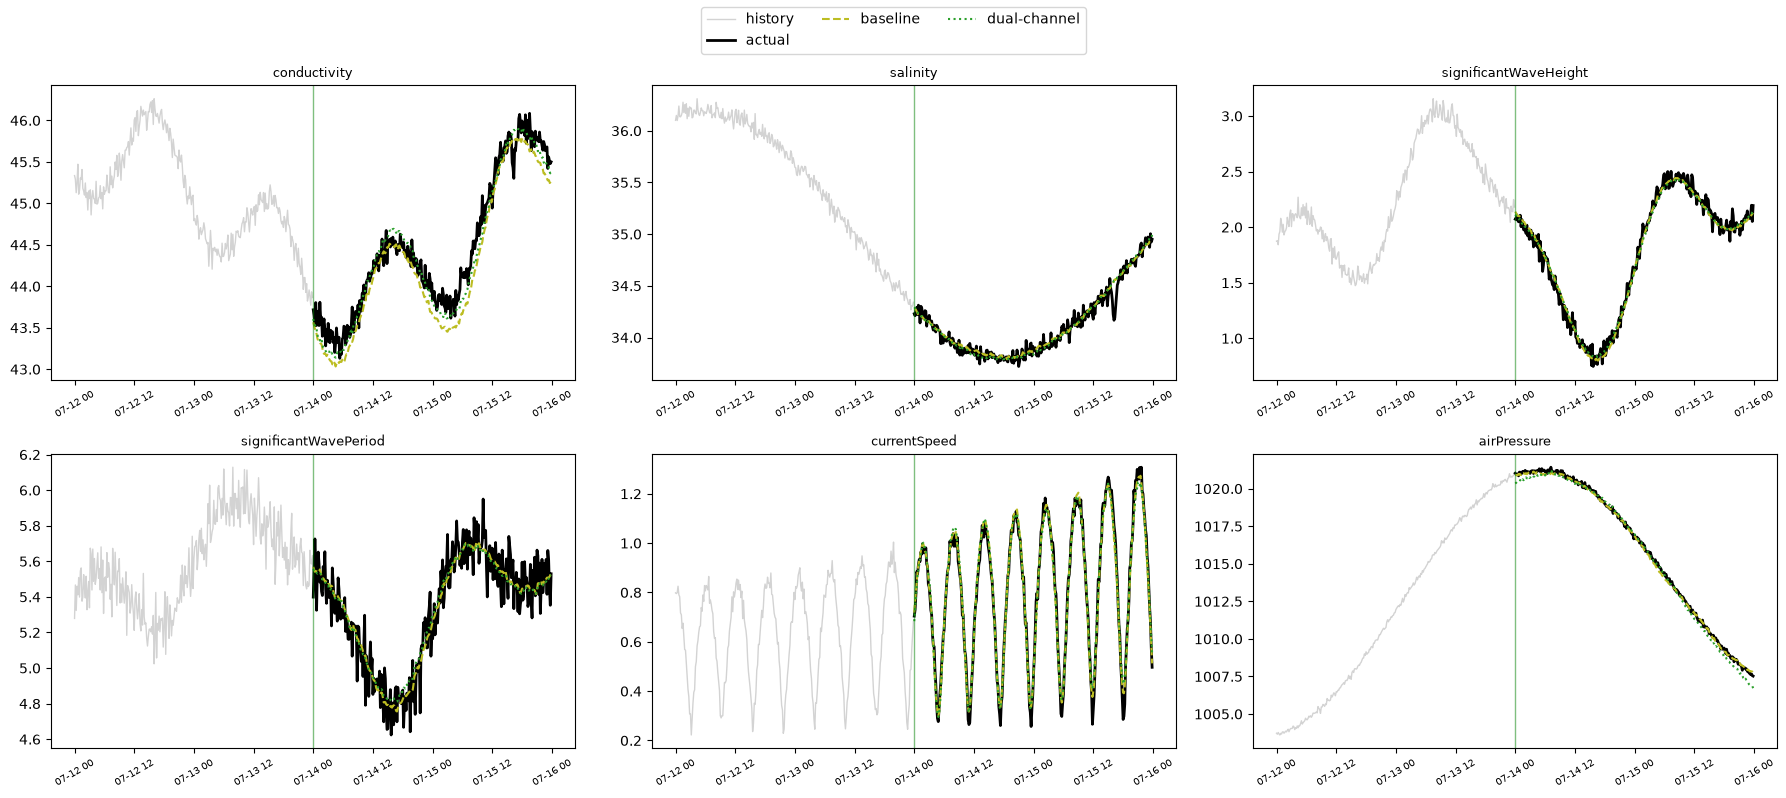

Saved dualchannel_ablation_plot.png  (top 3 = biggest gains, bottom 3 = biggest losses)


In [9]:
plot_params = metrics_df["parameter"].head(3).tolist() + metrics_df["parameter"].tail(3).tolist()
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), plot_params):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, baseline_final[c], color="#bcbd22", lw=1.5, ls="--", label="baseline")
    ax.plot(truth.index, dual_final[c], color="#2ca02c", lw=1.5, ls=":", label="dual-channel")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("dualchannel_ablation_plot.png", dpi=110)
plt.show()
print("Saved dualchannel_ablation_plot.png  (top 3 = biggest gains, bottom 3 = biggest losses)")

## 8. Save outputs

In [10]:
metrics_df.to_csv("metrics_dualchannel_ablation.csv", index=False)

fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__baseline"] = baseline_final[p].values
    fva[f"{p}__dualchannel"] = dual_final[p].values
fva.to_csv("forecast_vs_actual_dualchannel.csv", index=False)

print("Saved: metrics_dualchannel_ablation.csv, forecast_vs_actual_dualchannel.csv, dualchannel_ablation_plot.png")

Saved: metrics_dualchannel_ablation.csv, forecast_vs_actual_dualchannel.csv, dualchannel_ablation_plot.png


## 9. Conclusion

Section 6 is the actual verdict. This is an ablation, not a replacement decision made in advance —
if the dual-channel branch doesn't improve a clear majority of the 18 "good" parameters with a positive
mean delta, the honest conclusion is to keep the existing, simpler baseline iTransformer (already in
production use across `Marine_Forecast_RealEMS_iTransformer_Only.ipynb` and all 4 hybrid notebooks) and
not adopt the larger model for a benefit that doesn't clearly exist on this dataset.